**Copyright © 2023, Abhishek Hanchate, Satish T.S. Bukkapatnam, and Smart Manufacturing Advanced Research Team, Texas A&M University, All rights reserved.**

In [ ]:
__author__ = "Abhishek Hanchate"
__copyright__ = "Copyright (C) 2023 Abhishek Hanchate"
__version__ = "1.0"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import io
from google.colab import files
datapath = '/content/drive/My Drive/Ph. D. Research/CESMII Project/UTRGV-DL/'

In [ ]:
# Load libraries
import numpy as np
from keras.preprocessing.text import Tokenizer
from keras import models
from keras import layers
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
# Set random seed
np.random.seed(0)

In [ ]:
import tensorflow as tf
import os
import sys
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')
import keras
sys.stderr = stderr
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.metrics import BinaryAccuracy
from keras.callbacks import LearningRateScheduler

In [ ]:
import matplotlib as mpl
import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
import plotly.offline as py
import plotly.graph_objs as go
import cv2
import glob
import time
import datetime
import math

In [ ]:
import numpy as np
from scipy import signal
import scipy.io.wavfile as wav
from numpy.lib import stride_tricks
import matplotlib.pyplot as plt

""" short time fourier transform of audio signal """
def stft(sig, frameSize, overlapFac=0.5, window=np.hanning):
    win = window(frameSize)
    hopSize = int(frameSize - np.floor(overlapFac * frameSize))
    
    # zeros at beginning (thus center of 1st window should be for sample nr. 0)
    samples = np.append(np.zeros(np.int64(np.floor(frameSize/2.0))), sig)    
    # cols for windowing
    cols = np.int64(np.ceil( (len(samples) - frameSize) / float(hopSize)) + 1)
    # zeros at end (thus samples can be fully covered by frames)
    samples = np.append(samples, np.zeros(frameSize))
    
    frames = stride_tricks.as_strided(
            samples, shape=(cols, frameSize),
            strides=(samples.strides[0]*hopSize, samples.strides[0])).copy()
    frames *= win
    
    return np.fft.rfft(frames)    
    
""" scale frequency axis logarithmically """    
def logscale_spec(spec, sr=44100, factor=20.):
    timebins, freqbins = np.shape(spec)

    scale = np.linspace(0, 1, freqbins) ** factor
    scale *= (freqbins-1)/max(scale)
    scale = np.unique(np.round(scale))
    scale = np.int64(scale)
    
    # create spectrogram with new freq bins
    newspec = np.complex128(np.zeros([timebins, len(scale)]))
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            newspec[:,i] = np.sum(spec[:,scale[i]:], axis=1)
        else:        
            newspec[:,i] = np.sum(spec[:,scale[i]:scale[i+1]], axis=1)
    
    # list center freq of bins
    allfreqs = np.abs(np.fft.fftfreq(freqbins*2, 1./sr)[:freqbins+1])
    freqs = []
    for i in range(0, len(scale)):
        if i == len(scale)-1:
            freqs += [np.mean(allfreqs[scale[i]:])]
        else:
            freqs += [np.mean(allfreqs[scale[i]:scale[i+1]])]
    
    return newspec, freqs

""" plot spectrogram"""
def plotstft(samples, samplerate, binsize=2**10, 
        plotpath=None, colormap="jet", plot_artifacts=True):
    
    font = {'family': 'Calibri',
        'color':  'black',
        'weight': 'bold',
        'size': 28,
        }   

    s = stft(samples, binsize)
    
    sshow, freq = logscale_spec(s, factor=1.0, sr=samplerate)
    ims = 20.*np.log10(np.abs(sshow)/10e-6) # amplitude to decibel
    #ims = (np.abs(sshow))**(1/100) # amplitude to decibel
    
    timebins, freqbins = np.shape(ims)
    
    plt.figure(figsize=(15, 7.5))
    plt.imshow(np.transpose(ims), origin="lower", 
            aspect="auto", cmap=colormap, interpolation="none", vmin=25, vmax=125)
    # vmin = -0, vmax = 100
    if not plot_artifacts:
      plt.axis('off')
    else:
      plt.colorbar()
      plt.xlabel("Time (Sec)", fontdict = font)
      plt.ylabel("Frequency (Hz)", fontdict = font)
      plt.xlim([0, timebins-1])
      plt.ylim([0, freqbins])

      xlocs = np.float32(np.linspace(0, timebins-1, 5))
      plt.xticks(xlocs, ["%.02f" % l for l in 
          ((xlocs*len(samples)/timebins)+(0.5*binsize))/samplerate], fontsize = 24, fontweight = 'bold')

      ylocs = np.int16(np.round(np.linspace(0, freqbins-1, 10)))
      plt.yticks(ylocs, ["%.02f" % freq[i] for i in ylocs], fontsize = 24, fontweight = 'bold')
    
    if plotpath:
        plt.savefig(plotpath, bbox_inches="tight")
    else:
        plt.show()
    plt.clf()

In [ ]:
# Loading Pickle Files - 29th Sept 2022
data = pd.read_pickle(datapath + 'Experiment 1-4 datasets.pkl')
rates = pd.read_pickle(datapath + 'Experiment 1-4 rates.pkl')

In [ ]:
data

In [ ]:
for i in range(len(data)):
  mean = np.mean(data.iloc[i, :])
  data.iloc[i, :] = data.iloc[i, :] - mean

In [ ]:
datasets = data

In [ ]:
datasets.iloc[0, :]

In [ ]:
for i in range(1, 81): # 81
    signal_data = datasets.iloc[i-1, :]

    # plotstft(signal_data, 160000, binsize=2**13, plotpath = datapath + f'Spectrograms/spectro_{i}.png', \
    #                 colormap="jet", plot_artifacts=False)

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([0, 10000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(0-10000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([10000, 20000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(10000-20000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([20000, 30000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(20000-30000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([30000, 40000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(30000-40000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([40000, 50000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(40000-50000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([50000, 60000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(50000-60000)_{i}.png')
    _ = plt.close()

    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([60000, 70000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(60000-70000)_{i}.png')
    _ = plt.close()
    
    f = plt.figure()
    _ = plt.specgram(signal_data, Fs=160000, cmap="rainbow")
    _ = plt.ylim([70000, 80000])
    _ = plt.axis('off')
    f.savefig(datapath + f'Spectrograms_Freq_Ranged/spectro_(70000-80000)_{i}.png')
    _ = plt.close()

In [ ]:
# Skip 38 and 39 since issues with Spectrogram

# X1 = []
# X2 = []
# X3 = []
# X4 = []
# X5 = []
# X6 = []
# X7 = []
# X8 = []

for i in range(40, 81): # 81  # (1, 38) (40, 81)  

    img1 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(0-10000)_{i}.png") 
    X1.append(img1)

    img2 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(10000-20000)_{i}.png") 
    X2.append(img2)

    img3 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(20000-30000)_{i}.png") 
    X3.append(img3)

    img4 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(30000-40000)_{i}.png") 
    X4.append(img4)

    img5 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(40000-50000)_{i}.png") 
    X5.append(img5)

    img6 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(50000-60000)_{i}.png") 
    X6.append(img6)

    img7 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(60000-70000)_{i}.png") 
    X7.append(img7)

    img8 = cv2.imread(datapath + f"Spectrograms_Freq_Ranged/spectro_(70000-80000)_{i}.png") 
    X8.append(img8)

In [ ]:
len(X1)

78

In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220512/CESMIIExperiment 1-Calibration.xlsx')
y1 = y_data.Ra
y1 = y1.dropna()
print(pd.DataFrame(y1))

In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220516/CESMIIExperiment 2-Calibration..xlsx')
y2 = y_data.Ra
y2 = y2.dropna()
print(pd.DataFrame(y2))

In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220517/CESMIIExperiment 3-Calibration (2).xlsx')
y3 = y_data.Ra
y3 = y3.dropna()
print(pd.DataFrame(y3))

In [ ]:
y_data = pd.read_excel(datapath + 'CESMII220518/CESMIIExperiment 4-Calibration.xlsx')
y4 = y_data.Ra
y4 = y4.dropna()
print(pd.DataFrame(y4))

In [ ]:
y = y1.append(y2)
y = y.append(y3)
y = y.append(y4)
y

In [ ]:
yy = y.reset_index()
yy

In [ ]:
df_transpose = yy.T

In [ ]:
df_transpose.pop(37)

In [ ]:
df_transpose.pop(38)

In [ ]:
yyy = df_transpose.T
yyy

In [ ]:
y = yyy.Ra
y

In [ ]:
training_images1 = np.array(X1)
training_images2 = np.array(X2)
training_images3 = np.array(X3)
training_images4 = np.array(X4)
training_images5 = np.array(X5)
training_images6 = np.array(X6)
training_images7 = np.array(X7)
training_images8 = np.array(X8)

In [ ]:
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_1', training_images1)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_2', training_images2)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_3', training_images3)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_4', training_images4)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_5', training_images5)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_6', training_images6)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_7', training_images7)
np.save(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_8', training_images8)

In [ ]:
training_images1 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_1.npy')
training_images2 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_2.npy')
training_images3 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_3.npy')
training_images4 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_4.npy')
training_images5 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_5.npy')
training_images6 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_6.npy')
training_images7 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_7.npy')
training_images8 = np.load(datapath + '4thOct_CNN_Model_XTrain_TrainingImages_8.npy')

In [ ]:
# from skimage.transform import resize
# width, height = 512, 512
# resized = [resize(i, (width, height)) for i in X]
# training_images = np.array(resized)

In [ ]:
# smp_img = training_images[0].astype("float32") / 255.0
# lab = cv2.cvtColor(smp_img, cv2.COLOR_BGR2LAB)  BGR2HSV

In [ ]:
print(type(training_images1))
print(type(training_images2))
print(type(training_images3))
print(type(training_images4))
print(type(training_images5))
print(type(training_images6))
print(type(training_images7))
print(type(training_images8))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [ ]:
print(training_images1.shape)
print(training_images2.shape)
print(training_images3.shape)
print(training_images4.shape)
print(training_images5.shape)
print(training_images6.shape)
print(training_images7.shape)
print(training_images8.shape)
print(y.shape)

(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78, 288, 432, 3)
(78,)


In [ ]:
training_images = np.hstack(([training_images1, training_images2, training_images3, training_images4,\
                             training_images5, training_images6, training_images7, training_images8]))
# training_images = np.hstack(([training_images], [training_images3]))
# training_images = np.hstack(([training_images], [training_images4]))
# training_images = np.hstack(([training_images], [training_images5]))
# training_images = np.hstack(([training_images], [training_images6]))
# training_images = np.hstack(([training_images], [training_images7]))
# training_images = np.hstack(([training_images], [training_images8]))

In [ ]:
training_images.shape

(78, 2304, 432, 3)

In [ ]:
training_images1.shape

(78, 288, 432, 3)

In [ ]:
training_images

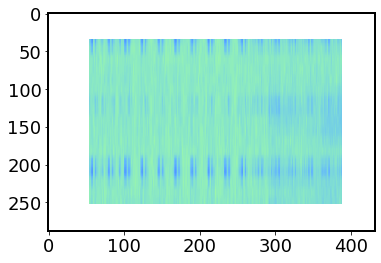

In [ ]:
from matplotlib import pyplot as plt
plt.imshow(training_images4[0], interpolation='nearest')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_Train, X_Valid, y_Train, y_Valid = train_test_split(training_images, y, test_size=0.25)

In [ ]:
# 8 Freq Range - Images - 8 Models
np.random.seed(12345)
X_Train1, X_Valid1, y_Train1, y_Valid1 = train_test_split(training_images1, y, test_size=0.25)
X_Train2, X_Valid2, y_Train2, y_Valid2 = train_test_split(training_images2, y, test_size=0.25)
X_Train3, X_Valid3, y_Train3, y_Valid3 = train_test_split(training_images3, y, test_size=0.25)
X_Train4, X_Valid4, y_Train4, y_Valid4 = train_test_split(training_images4, y, test_size=0.25)
X_Train5, X_Valid5, y_Train5, y_Valid5 = train_test_split(training_images5, y, test_size=0.25)
X_Train6, X_Valid6, y_Train6, y_Valid6 = train_test_split(training_images6, y, test_size=0.25)
X_Train7, X_Valid7, y_Train7, y_Valid7 = train_test_split(training_images7, y, test_size=0.25)
X_Train8, X_Valid8, y_Train8, y_Valid8 = train_test_split(training_images8, y, test_size=0.25)

In [ ]:
# Changer
X_Train1 = training_images1[:58, :, :, :]
X_Valid1 = training_images1[58:, :, :, :]
X_Train2 = training_images2[:58, :, :, :]
X_Valid2 = training_images2[58:, :, :, :]
X_Train3 = training_images3[:58, :, :, :]
X_Valid3 = training_images3[58:, :, :, :]
X_Train4 = training_images4[:58, :, :, :]
X_Valid4 = training_images4[58:, :, :, :]
X_Train5 = training_images5[:58, :, :, :]
X_Valid5 = training_images5[58:, :, :, :]
X_Train6 = training_images6[:58, :, :, :]
X_Valid6 = training_images6[58:, :, :, :]
X_Train7 = training_images7[:58, :, :, :]
X_Valid7 = training_images7[58:, :, :, :]
X_Train8 = training_images8[:58, :, :, :]
X_Valid8 = training_images8[58:, :, :, :]
y_Train = y[:58]
y_Valid = y[58:]

In [ ]:
import tensorflow as tf
import keras
from keras import layers
from keras import models
from keras import utils
from keras.layers import Dense
from keras.models import Sequential
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import Activation
from keras.regularizers import l2
from keras import datasets
from keras.callbacks import LearningRateScheduler
from keras.callbacks import History
from keras import losses
from sklearn.utils import shuffle

In [ ]:
X_Train4.shape

(58, 288, 432, 3)

In [ ]:
print(X_Train1)
print(y_Train1)
print(X_Valid1)
print(y_Valid1)

In [ ]:
X_Train1.shape[1:]

(288, 432, 3)

In [ ]:
print(type(X_Train1))
print(type(y_Train1))
print(type(X_Valid1))
print(type(y_Valid1))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


In [ ]:
print(len(X_Train1))
print(len(y_Train1))
print(len(X_Valid1))
print(len(y_Valid1))

58
58
20
20


In [ ]:
X_Train1.shape

(58, 288, 432, 3)

In [ ]:
y_Train1.shape

(58,)

In [ ]:
X_Train_backup = X_Train
X_Valid_backup = X_Valid
y_Train_backup = y_Train
y_Valid_backup = y_Valid

In [ ]:
X_Train1, X_Valid1, y_Train1, y_Valid1
X_Train2, X_Valid2, y_Train2, y_Valid2
X_Train3, X_Valid3, y_Train3, y_Valid3
X_Train4, X_Valid4, y_Train4, y_Valid4
X_Train5, X_Valid5, y_Train5, y_Valid5
X_Train6, X_Valid6, y_Train6, y_Valid6
X_Train7, X_Valid7, y_Train7, y_Valid7
X_Train8, X_Valid8, y_Train8, y_Valid8

In [ ]:
y_Train1.head(5)

56    0.08700
42    0.07575
72    0.11150
18    0.11550
9     0.12625
Name: Ra, dtype: float64

In [ ]:
y_Train2.head(5)

27    0.08225
35    0.06975
65    0.13525
16    0.11875
43    0.06850
Name: Ra, dtype: float64

In [ ]:
# Multiple Inputs
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.pooling import MaxPooling2D
from keras.layers.merge import concatenate

# first input model
visible1 = Input(shape=(288, 432, 3))
conv11 = Conv2D(16, kernel_size=(3, 3), activation='relu')(visible1)
pool11 = MaxPooling2D(pool_size=(2, 2))(conv11)
# conv12 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool11)
# pool12 = MaxPooling2D(pool_size=(2, 2))(conv12)
flat1 = Flatten()(pool11)

# second input model
visible2 = Input(shape=(288, 432, 3))
conv21 = Conv2D(16, kernel_size=(3, 3), activation='relu')(visible2)
pool21 = MaxPooling2D(pool_size=(2, 2))(conv21)
# conv22 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool21)
# pool22 = MaxPooling2D(pool_size=(2, 2))(conv22)
flat2 = Flatten()(pool21)

# first input model
visible3 = Input(shape=(288, 432, 3))
conv31 = Conv2D(16, kernel_size=(3, 3), activation='relu')(visible3)
pool31 = MaxPooling2D(pool_size=(2, 2))(conv31)
# conv12 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool11)
# pool12 = MaxPooling2D(pool_size=(2, 2))(conv12)
flat3 = Flatten()(pool31)

# second input model
visible4 = Input(shape=(288, 432, 3))
conv41 = Conv2D(16, kernel_size=(3, 3), activation='relu')(visible4)
pool41 = MaxPooling2D(pool_size=(2, 2))(conv41)
# conv22 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool21)
# pool22 = MaxPooling2D(pool_size=(2, 2))(conv22)
flat4 = Flatten()(pool41)

# # first input model
# visible5 = Input(shape=(288, 432, 3))
# conv51 = Conv2D(64, kernel_size=(3, 3), activation='relu')(visible5)
# pool51 = MaxPooling2D(pool_size=(2, 2))(conv51)
# # conv12 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool11)
# # pool12 = MaxPooling2D(pool_size=(2, 2))(conv12)
# flat5 = Flatten()(pool51)

# # second input model
# visible6 = Input(shape=(288, 432, 3))
# conv61 = Conv2D(64, kernel_size=(3, 3), activation='relu')(visible6)
# pool61 = MaxPooling2D(pool_size=(2, 2))(conv61)
# # conv22 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool21)
# # pool22 = MaxPooling2D(pool_size=(2, 2))(conv22)
# flat6 = Flatten()(pool61)

# # first input model
# visible7 = Input(shape=(288, 432, 3))
# conv71 = Conv2D(64, kernel_size=(3, 3), activation='relu')(visible7)
# pool71 = MaxPooling2D(pool_size=(2, 2))(conv71)
# # conv12 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool11)
# # pool12 = MaxPooling2D(pool_size=(2, 2))(conv12)
# flat7 = Flatten()(pool71)

# # second input model
# visible8 = Input(shape=(288, 432, 3))
# conv81 = Conv2D(64, kernel_size=(3, 3), activation='relu')(visible8)
# pool81 = MaxPooling2D(pool_size=(2, 2))(conv81)
# # conv22 = Conv2D(16, kernel_size=(3, 3), activation='relu')(pool21)
# # pool22 = MaxPooling2D(pool_size=(2, 2))(conv22)
# flat8 = Flatten()(pool81)


# merge input models
merge = concatenate([flat1, flat2, flat3, flat4]) #, flat5, flat6, flat7, flat8])
# interpretation model
hidden1 = Dense(16, activation='relu')(merge)
# hidden2 = Dense(16, activation='relu')(hidden1)
output = Dense(1, activation='linear')(hidden1)
model = Model(inputs=[visible1, visible2, visible3, visible4], outputs=output)#, visible5, visible6, visible7, visible8]
# summarize layers
print(model.summary())

In [ ]:
from keras import optimizers
# , X_Train5, X_Train6, X_Train7, X_Train8
# , X_Valid5, X_Valid6, X_Valid7, X_Valid8
adam = tf.keras.optimizers.Adam(learning_rate = 0.001, beta_1 = 0.9, beta_2 = 0.99, amsgrad = False)
model.compile(loss='mae', optimizer=adam, metrics=['mse'])
history = model.fit([X_Train1, X_Train2, X_Train3, X_Train4], y_Train, epochs = 50, batch_size = 12, \
                    validation_data=([X_Valid1, X_Valid2, X_Valid3, X_Valid4], y_Valid), shuffle=True, verbose=1) 

In [ ]:
# Initialize Neural Network model
# define the model
m = Sequential()
m.add(Dense(64, activation="relu", input_shape=X_Train.shape[1:]))
m.add(Dense(32, activation='relu'))
m.add(layers.Flatten())
m.add(Dense(8, activation='relu'))
m.add(Dense(1, activation='linear'))
#m.summary()

In [ ]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation=tf.nn.relu, input_shape=X_Train1.shape[1:]))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
# model.add(tf.keras.layers.Conv2D(16, kernel_size=(2, 2), activation=tf.nn.relu, input_shape=X_Train.shape[1:]))
# model.add(tf.keras.layers.MaxPooling2D(pool_size=(1,1)))
model.add(tf.keras.layers.Flatten()) 
#model.add(tf.keras.layers.Dense(128, activation = tf.nn.relu, input_shape=X_Train.shape[1:]))
#model.add(tf.keras.layers.Dense(128, activation = tf.nn.relu,))
model.add(tf.keras.layers.Dense(64, activation = tf.nn.relu))
model.add(tf.keras.layers.Dense(1, activation = 'linear'))

In [ ]:
from keras import optimizers
# , X_Train5, X_Train6, X_Train7, X_Train8
# , X_Valid5, X_Valid6, X_Valid7, X_Valid8
adam = tf.keras.optimizers.Adam(learning_rate = 0.1, beta_1 = 0.5, beta_2 = 0.59, amsgrad = False)
model.compile(loss='mae', optimizer=adam, metrics=['mse'])
history = model.fit(X_Train1, y_Train, epochs = 50, batch_size = 12, \
                    validation_data=(X_Valid1, y_Valid), shuffle=True, verbose=1) 

Epoch 1/50
5/5 [==============================] - 14s 3s/step - loss: 0.0446 - mse: 0.0030 - val_loss: 0.0706 - val_mse: 0.0052
Epoch 2/50
5/5 [==============================] - 13s 3s/step - loss: 0.0335 - mse: 0.0014 - val_loss: 0.0376 - val_mse: 0.0017
Epoch 3/50
5/5 [==============================] - 13s 3s/step - loss: 0.0249 - mse: 0.0010 - val_loss: 0.0284 - val_mse: 0.0010
Epoch 4/50
5/5 [==============================] - 13s 3s/step - loss: 0.0336 - mse: 0.0016 - val_loss: 0.0437 - val_mse: 0.0021
Epoch 5/50
5/5 [==============================] - 13s 3s/step - loss: 0.0246 - mse: 8.2147e-04 - val_loss: 0.0347 - val_mse: 0.0014
Epoch 6/50
5/5 [==============================] - 13s 3s/step - loss: 0.0251 - mse: 0.0010 - val_loss: 0.0450 - val_mse: 0.0023
Epoch 7/50
5/5 [==============================] - 13s 3s/step - loss: 0.0289 - mse: 0.0012 - val_loss: 0.0291 - val_mse: 0.0011
Epoch 8/50
5/5 [==============================] - 13s 3s/step - loss: 0.0260 - mse: 9.9383e-04 - val

In [ ]:
# make predictions
y_Pred = model.predict([training_images1, training_images2, training_images3, training_images4])
y_Pred

In [ ]:
# make predictions
y_Pred = model.predict(training_images1)
y_Pred

array([[0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],
       [0.0849802],


In [ ]:
y

0     0.11375
1     0.11600
2     0.13850
3     0.12850
4     0.12500
       ...   
75    0.12725
76    0.09550
77    0.10250
78    0.12125
79    0.11900
Name: Ra, Length: 78, dtype: float64

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_Pred)
mse

0.0007786279943123851

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y, y_Pred)
r2_score

-0.3396953251362025

In [ ]:
model.save(datapath + '29thSept_CNN_Model_2_R2_0.95.h5')

In [ ]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 58, 318, 64)       1792      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 29, 159, 64)      0         
 2D)                                                             
                                                                 
 flatten_5 (Flatten)         (None, 295104)            0         
                                                                 
 dense_10 (Dense)            (None, 64)                18886720  
                                                                 
 dense_11 (Dense)            (None, 1)                 65        
                                                                 
Total params: 18,888,577
Trainable params: 18,888,577
Non-trainable params: 0
__________________________________________

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_XTrain', X_Train)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_yTrain', y_Train)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_XValid', X_Valid)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_yValid', y_Valid)

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_X', training_images)
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_y', y)

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_Loss', history.history['loss'])
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_ValLoss', history.history['val_loss'])

In [ ]:
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_MSE', history.history['mse'])
np.save(datapath + '29thSept_CNN_Model_2_R2_0.95_ValMSE', history.history['val_mse'])

In [ ]:
history.history['val_loss']

In [ ]:
history.history['mse']

In [ ]:
# make predictions
y_Pred = model.predict(X_Valid)
y_Pred

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y_Valid, y_Pred)
r2_score

0.7836096907893153

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_Valid, y_Pred)
mse

0.00015225162047644548

In [ ]:
# Load Model 1 and Preds
model1 = tf.keras.models.load_model(datapath + '28thSept_CNN_Model_4.h5')

In [ ]:
y_Pred1 = model1.predict(training_images)
y_Pred1

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y, y_Pred1)
mse

0.0009345477643667235

In [ ]:
from sklearn.metrics import r2_score
r2_score = r2_score(y, y_Pred1)
r2_score

-0.6079684781231789

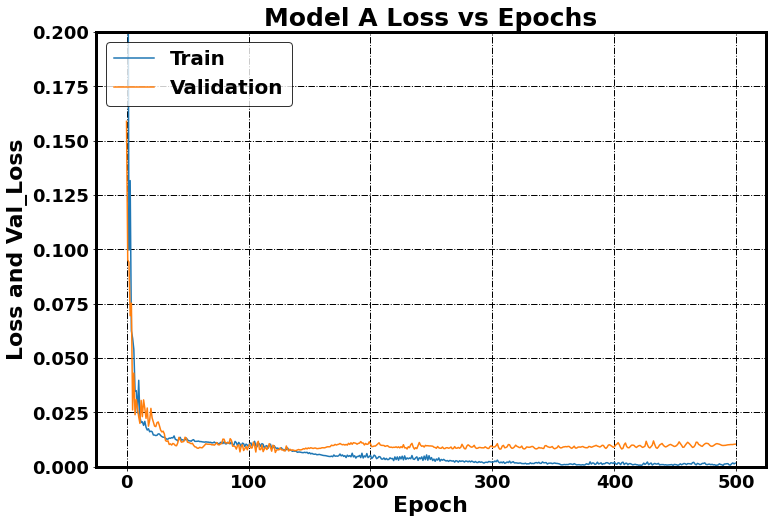

In [ ]:
# summarize history for loss
plt.figure(facecolor='white')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model A Loss vs Epochs', fontsize=25, fontweight="bold",fontfamily="Arial")
plt.ylabel('Loss and Val_Loss', fontsize=22, fontweight="bold",fontfamily="Arial")
plt.xlabel('Epoch',fontsize= 22, fontweight="bold",fontfamily="Arial")
plt.xticks(fontsize=18,fontfamily="Arial", fontweight="bold")
plt.yticks(fontsize=18,fontfamily="Arial", fontweight="bold")
#plt.xlim([-50, 2050])
plt.ylim([0, 0.2])

plt.grid(color='black', linestyle='-.', linewidth=1)
plt.rcParams.update({'axes.linewidth': 3})
legend = plt.legend(['Train', 'Validation'], loc='upper left', prop={'size': 20,'family' : 'Arial', 'weight':'bold'})
fig = plt.gcf()
fig.set_size_inches(12, 8, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
plt.show()

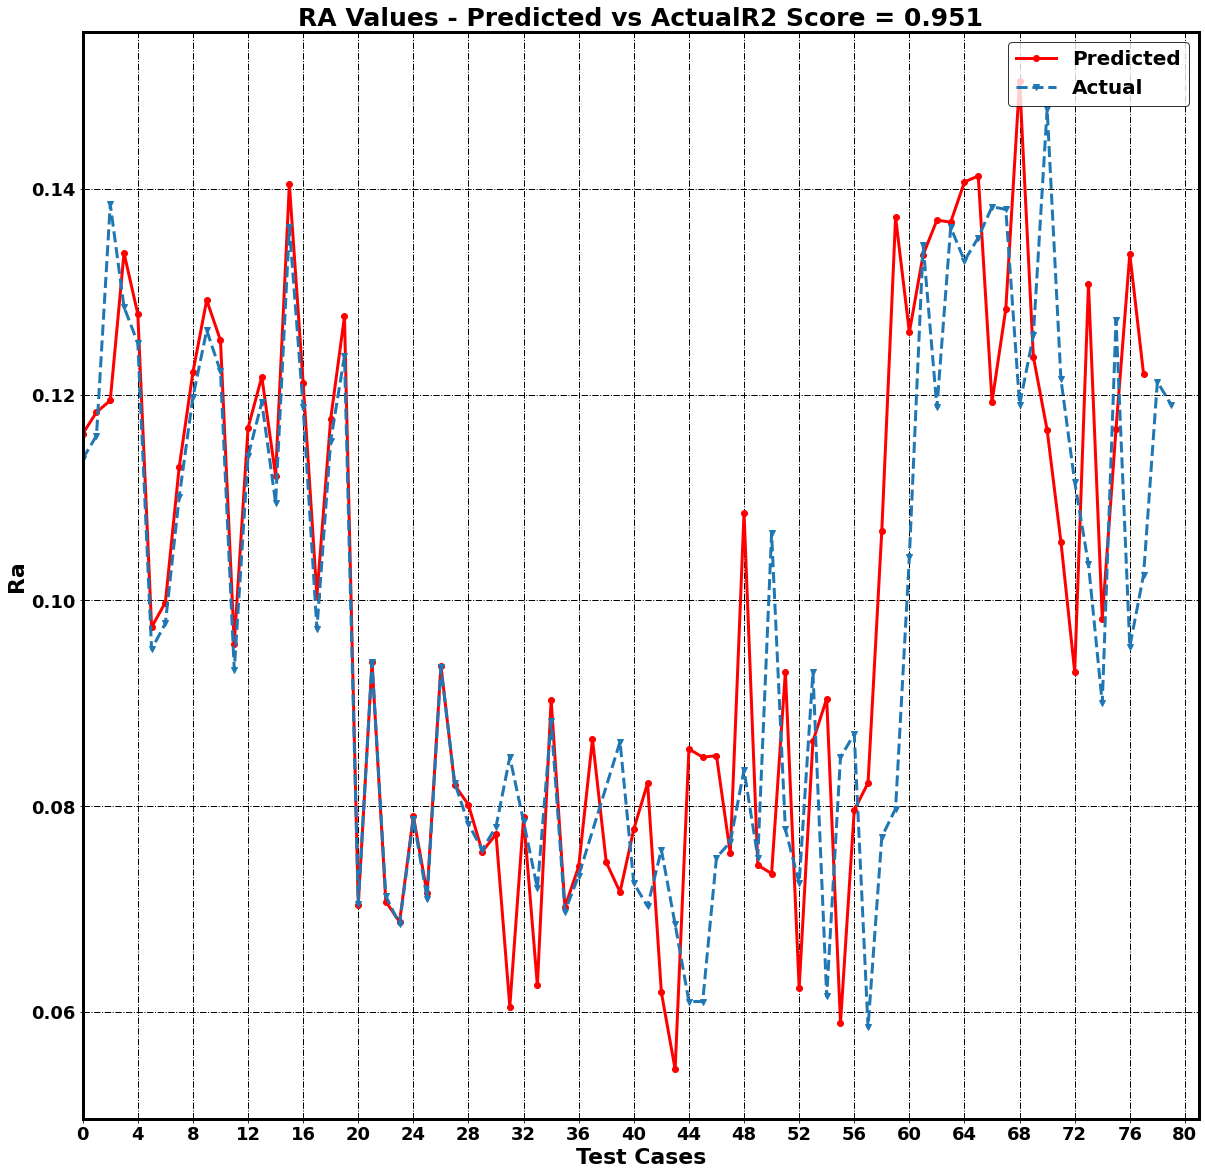

In [ ]:
testlen = 80
from sklearn.metrics import r2_score
plt.figure(facecolor='white')
plt.title('RA Values - Predicted vs Actual' + "R2 Score = {:.3f}".format(r2_score(y, y_Pred)), fontsize=25, fontweight="bold",fontfamily="Arial")
plt.plot(y_Pred, label = 'Predicted',marker = 'o',color ='r',linewidth=3)
plt.plot(y, label = 'Actual',linestyle = '--',marker = 'v',linewidth=3)

plt.xlabel('Test Cases', fontsize=22, fontweight="bold",fontfamily="Arial")
plt.ylabel('Ra', fontsize=22, fontweight="bold",fontfamily="Arial")
plt.xticks(np.arange(0, testlen+1, 4),fontsize=18,fontfamily="Arial", fontweight="bold")
plt.yticks(fontsize=18,fontfamily="Arial", fontweight="bold")
plt.xlim([0, testlen+1])

#plt.ylim([0, 400])
plt.grid(color='black',linestyle='-.',linewidth=1)
plt.rcParams.update({'axes.linewidth': 3})
plt.legend(loc='upper right',facecolor='white', edgecolor='black', prop={'size': 20,'family' : 'Arial','weight':'bold'})
fig = plt.gcf()
fig.set_size_inches(20,20, forward=True)
ax = fig.gca()
ax.spines["top"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["right"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.set_facecolor("white")
plt.show()

In [ ]:
model = tf.keras.models.load_model(datapath + '28thSept_CNN_Model.h5')

In [ ]:
!pip install lime

In [ ]:
import lime
import lime.lime_tabular
from lime import lime_image

In [ ]:
explainer = lime_image.LimeImageExplainer()

In [ ]:
y_samp = [0.11375]

In [ ]:
sample = []
for i in range(1, 2): # 81
  img = cv2.imread(datapath + f"Spectrograms/spectro_matplot_{i}.png")
  #imgg = img.flatten()
  sample.append(img)
print(sample)

In [ ]:
from skimage.transform import resize
width, height = 512, 512
resized_sample = [resize(i, (width, height)) for i in sample]
training_images_sample = np.array(resized_sample)

In [ ]:
pred = model.predict(training_images_sample)
pred

array([[0.11465628]], dtype=float32)

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.DeepExplainer(model = model, data = training_images_sample)
shap_values = explainer.shap_values(training_images_sample)

shap_values = shap_values[0].reshape(-1)
X_test = training_images_sample.reshape(-1)

shap.summary_plot(shap_values, X_test)

In [ ]:
explainer = lime_image.LimeImageExplainer(random_state=123)
explainer

In [ ]:
explanation = explainer.explain_instance(training_images_sample, model.predict(training_images_sample), random_seed=123)
explanation

RuntimeError: ignored

In [ ]:
img, mask = explanation.get_image_and_mask(Y_test[idx], positive_only=True, hide_rest=True)
img.shape, mask.shape

In [ ]:
LX = np.load('markers_dataset_trial/LX.npy')
LY = np.load('markers_dataset_trial/LY.npy')

model = load_model('marker_model_fold_no_10.h5')
pred = model.predict(LX)

LY = np.array([1 if a == 0 else 0 for a in LY])  # reversing 0 and 1

from sklearn.preprocessing import OneHotEncoder
Y_new = OneHotEncoder().fit_transform(LY.reshape((-1,1))).toarray()

pred_class = [1 if a < 0.5 else 0 for a in pred]
correct_X_ind = list(np.where(pred_class==LY)[0])
len(correct_X_ind)

In [ ]:
import lime
from lime import lime_image
from matplotlib import pyplot as plt
fname_out = 'C:\\Users\\data_and_code_Dec31\\Shallow_markers'

seg_fn = 'quickshift'
if seg_fn == 'quickshift':
    k_size = 5   # number of s-pixels
    num_s = 100   # number of perturbed samples
elif seg_fn == 'slic': 
    k_size = 200
    num_s = 400
    
explainer = lime_image.LimeImageExplainer()
score = []
# Input the sample_index corresponding to every image (from 1 to 123)
for sample_ind in correct_X_ind:

# sample_ind = 27
    sample = LX[sample_ind, :, :, :].astype('double')
    y_samp = LY[sample_ind]     # Change accordingly for different seg_fn
    explanation = explainer.explain_instance(sample, model, top_labels=2, hide_color=0, num_samples=num_s, num_features = k_size)
    score.append(explanation.score)

    if explanation.score > 0.75 and explanation.score <= 1:
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features = k_size, hide_rest=False)
        plt.figure(figsize = (12,8))
        plt.subplot(1, 2, 1)
        plt.imshow(sample)
        plt.subplot(1, 2, 2)
        plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
        if y_samp == 0:
          plt.suptitle('No marker',fontsize= 14, fontweight = 'bold')
        else:
          plt.suptitle('With marker',fontsize= 14, fontweight = 'bold')
        plt.savefig(fname_out+'\\local results\\'+str(sample_ind)+'_LIME_topten_plot.png',dpi = 400)
        plt.close()

        # save weights and watershed/lime ratios
        weightRatio = []
        for i, e in explanation.local_exp[explanation.top_labels[0]]:
            weightRatio.append((i, e, explanation.local_pred[explanation.top_labels[0]],explanation.intercept[explanation.top_labels[0]],explanation.top_labels[0]))
  
        WR = pd.DataFrame(weightRatio)
        WR.to_csv(fname_out+ str(sample_ind)+'_weightRatioPred_score'+str(round(explanation.score,2))+'_numseg'+str(len(explanation.local_exp[explanation.top_labels[0]]))+'.csv', index = False)
        
            
score = np.array(score)
np.save(fname_out+'\\'+seg_fn+'kerns'+str(k_size)+'_nums'+str(num_s)+'score.npy',score)